# Etapa 1. Conociendo el negocio
## Comprensión y preparación de los datos
### Alberto José Corella Moreno | A01255649
### Josué Uziel Ocañas Hernández | A01384725
### Javier Ogueta Burgaleta | A01833375
### 27/08/2026

## 1) Comprensión de los datos

### Forma del dataset

In [ ]:
import pandas as pd

# Cargar el dataset completo (todas las hojas)
xls = pd.ExcelFile('dataset_limpio_SIMA.xlsx')

# Todas las hojas contienen registros de contaminación del aire excepto por la primer hoja (el Índice, así que lo omitimos)
# Cada hoja contiene los registros de contaminantes para una estación en un año
# Ejemplo: 2020 NTE, 2021 NTE, 2022 NTE... así para cada estación.
hojas_datos = [h for h in xls.sheet_names if h != 'Índice']

frames = []
resumen_forma = []

for hoja in hojas_datos:
    df = pd.read_excel(xls, sheet_name=hoja)
    año, estacion = hoja.split('_', 1)

    resumen_forma.append({'Año': año, 'Estación': estacion, 'Filas': df.shape[0], 'Columnas': df.shape[1]})

    df['Año'] = año
    df['Estación'] = estacion
    frames.append(df)

# Forma de cada hoja
df_forma = pd.DataFrame(resumen_forma)

# Cargamos un dataset integrado completo (este usaremos para hacer el resto de la comprensión de datos)
df_maestro = pd.concat(frames, ignore_index=True)

print("Filas y columnas por cada estación cada año (cada hoja)")
df_forma

Filas y columnas por cada estación cada año (cada hoja)


,Año,Estación,Filas,Columnas
0,2020,CE,8784,16
1,2020,NE,8776,16
2,2020,NE2,8776,16
3,2020,NO,8778,16
4,2020,NO2,8776,16
...,...,...,...,...
82,2025,SE2,8759,16
83,2025,SE3,8758,16
84,2025,SO,8758,16
85,2025,SO2,8758,16


### Descripción de las variables

In [ ]:
# Descripciones de negocio para cada variable (según catálogo SIMA)
# Recordatorio: TOUT->TEMP, PRS->BP, WSR->WS, WDR->WD fueron renombradas en la etapa
descripciones = {
    'Fecha':    'Fecha y hora del registro (medición horaria)',
    'PM10':     'Material Particulado menor a 10 micrómetros (µg/m³)',
    'PM2.5':    'Material Particulado menor a 2.5 micrómetros (µg/m³)',
    'O3':       'Ozono (ppb)',
    'SO2':      'Dióxido de Azufre (ppb)',
    'NO2':      'Dióxido de Nitrógeno (ppb)',
    'CO':       'Monóxido de Carbono (ppm)',
    'NO':       'Monóxido de Nitrógeno (ppb)',
    'NOX':      'Suma de NO + NO2 (ppb)',
    'TEMP':     'Temperatura (°C) [originalmente TOUT]',
    'RH':       'Humedad Relativa (%)',
    'SR':       'Radiación Solar (kW/m²)',
    'RAINF':    'Precipitación (mm/Hr)',
    'BP':       'Presión Atmosférica (mm Hg) [originalmente PRS]',
    'WS':       'Velocidad del Viento (Km/hr) [originalmente WSR]',
    'WD':       'Dirección del Viento (°) [originalmente WDR]',
    'Año':      'Año en que se registró la medición',
    'Estación': 'Estación de monitoreo donde se tomó la medición',
}

filas = []
for col in df_maestro.columns:
    dtype = df_maestro[col].dtype
    es_numerica = pd.api.types.is_numeric_dtype(dtype)
    tipo = 'Numérico' if es_numerica else 'Categórico'

    n_nulos = df_maestro[col].isnull().sum()
    pct_nulos = 100 * n_nulos / len(df_maestro)

    filas.append({
        'Variable': col,
        'Descripción': descripciones.get(col, 'Pendiente de describir'),
        'Tipo': tipo,
        'Valores nulos': n_nulos,
        '% Nulos': round(pct_nulos, 2)
    })

df_descripcion_variables = pd.DataFrame(filas)
df_descripcion_variables

,Variable,Descripción,Tipo,Valores nulos,% Nulos
0,Fecha,Fecha y hora del registro (medición horaria),Categórico,0,0.00
1,CO,Monóxido de Carbono (ppm),Numérico,0,0.00
2,NO,Monóxido de Nitrógeno (ppb),Numérico,26331,3.49
3,NO2,Dióxido de Nitrógeno (ppb),Numérico,35107,4.65
4,NOX,Suma de NO + NO2 (ppb),Numérico,26332,3.49
5,O3,Ozono (ppb),Numérico,8776,1.16
6,PM10,Material Particulado menor a 10 micrómetros (µ...,Numérico,0,0.00
7,PM2.5,Material Particulado menor a 2.5 micrómetros (...,Numérico,44560,5.91
8,BP,Presión Atmosférica (mm Hg) [originalmente PRS],Numérico,0,0.00
9,RAINF,Precipitación (mm/Hr),Numérico,0,0.00


### Posibles valores de cada variable por año (no se alcanza a ver en la tabla descriptiva de variables)

In [ ]:
# Rangos de operación SIMA por año (mismos valid_ranges de la etapa 1)
valid_ranges = {
    2020: {'PM10': (0,800), 'PM2.5': (0,205.94), 'O3': (0,153), 'NO': (0,500), 'NO2': (0,200), 'NOX': (0,500), 'SO2': (0,200), 'CO': (0,20), 'RH': (0,100), 'WS': (0,75), 'TEMP': (0,41), 'SR': (0,1), 'BP': (690,750), 'WD': (0,360), 'RAINF': (0,30)},
    2021: {'PM10': (0,800), 'PM2.5': (0,325), 'O3': (0,175), 'NO': (0,350), 'NO2': (0,100), 'NOX': (0,400), 'SO2': (0,300), 'CO': (0,10), 'RH': (0,100), 'WS': (0,40), 'TEMP': (-6.5,45), 'SR': (0,1), 'BP': (690,740), 'WD': (0,360), 'RAINF': (0,80)},
    2022: {'PM10': (0,999), 'PM2.5': (0,450), 'O3': (0,160), 'NO': (0,400), 'NO2': (0,175), 'NOX': (0,420), 'SO2': (0,200), 'CO': (0,8), 'RH': (0,100), 'WS': (0,35), 'TEMP': (-5,45), 'SR': (0,1.25), 'BP': (700,740), 'WD': (0,360), 'RAINF': (0,25)},
    2023: {'PM10': (0,900), 'PM2.5': (0,800), 'O3': (0,175), 'NO': (0,500), 'NO2': (0,175), 'NOX': (0,500), 'SO2': (0,250), 'CO': (0,14), 'RH': (0,100), 'WS': (0,40), 'TEMP': (0,45), 'SR': (0,1), 'BP': (690,740), 'WD': (0,360), 'RAINF': (0,70)},
    2024: {'PM10': (0,999), 'PM2.5': (0,999), 'O3': (0,180), 'NO': (0,400), 'NO2': (0,130), 'NOX': (0,500), 'SO2': (0,150), 'CO': (0,18), 'RH': (0,100), 'WS': (0,38), 'TEMP': (-4,45.5), 'SR': (0,1.26), 'BP': (687.5,740), 'WD': (0,360), 'RAINF': (0,50)},
    2025: {'PM10': (0,820), 'PM2.5': (0,350), 'O3': (0,185), 'NO': (0,350), 'NO2': (0,175), 'NOX': (0,400), 'SO2': (0,405), 'CO': (0,10), 'RH': (0,100), 'WS': (0,40), 'TEMP': (-4.5,45), 'SR': (0,1.2), 'BP': (688,740), 'WD': (0,360), 'RAINF': (0,25)},
}

filas_rango = []
for year, ranges in sorted(valid_ranges.items()):
    fila = {'Año': year}
    for var, (vmin, vmax) in ranges.items():
        fila[var] = f"{vmin}-{vmax}"
    filas_rango.append(fila)

df_rangos_operacion = pd.DataFrame(filas_rango)
df_rangos_operacion

,Año,PM10,PM2.5,O3,NO,NO2,NOX,SO2,CO,RH,WS,TEMP,SR,BP,WD,RAINF
0,2020,0-800,0-205.94,0-153,0-500,0-200,0-500,0-200,0-20,0-100,0-75,0-41,0-1,690-750,0-360,0-30
1,2021,0-800,0-325,0-175,0-350,0-100,0-400,0-300,0-10,0-100,0-40,-6.5-45,0-1,690-740,0-360,0-80
2,2022,0-999,0-450,0-160,0-400,0-175,0-420,0-200,0-8,0-100,0-35,-5-45,0-1.25,700-740,0-360,0-25
3,2023,0-900,0-800,0-175,0-500,0-175,0-500,0-250,0-14,0-100,0-40,0-45,0-1,690-740,0-360,0-70
4,2024,0-999,0-999,0-180,0-400,0-130,0-500,0-150,0-18,0-100,0-38,-4-45.5,0-1.26,687.5-740,0-360,0-50
5,2025,0-820,0-350,0-185,0-350,0-175,0-400,0-405,0-10,0-100,0-40,-4.5-45,0-1.2,688-740,0-360,0-25


### Matriz de correlación
Nuestro estudio tiene enfoque en el PM10, así que queremos ver qué variables son relevantes para determinar los niveles de este contaminante en específico.

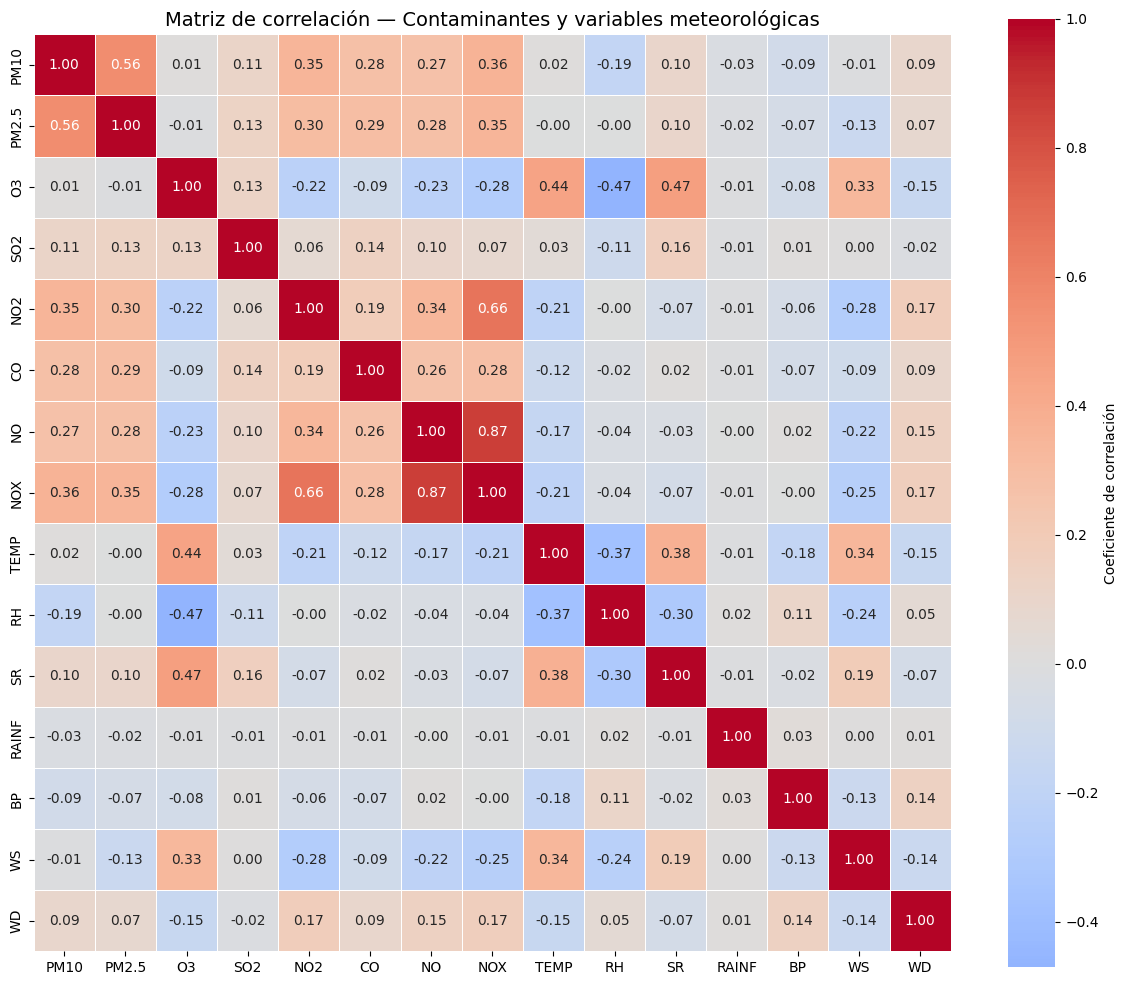

Correlación de cada variable con PM10 (ordenado por valor absoluto de mayor a menor):

PM2.5    0.559418
NOX      0.359168
NO2      0.350132
CO       0.277037
NO       0.268636
RH      -0.185394
SO2      0.110895
SR       0.100379
WD       0.092537
BP      -0.085464
RAINF   -0.025938
TEMP     0.016561
O3       0.010663
WS      -0.007711
Name: PM10, dtype: float64


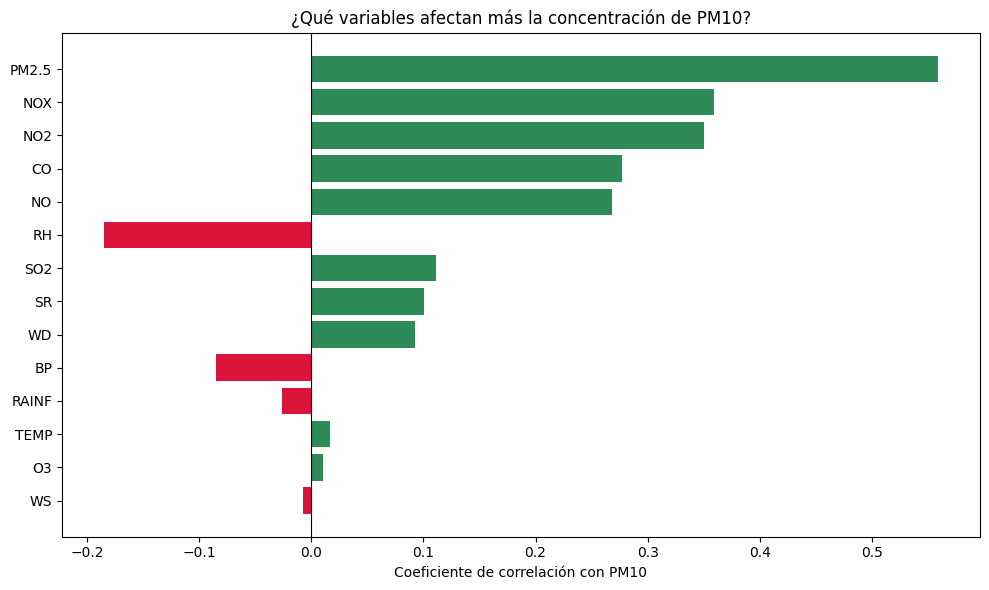

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas numéricas de interés (contaminantes + meteorológicas)
variables = ['PM10', 'PM2.5', 'O3', 'SO2', 'NO2', 'CO', 'NO', 'NOX',
                        'TEMP', 'RH', 'SR', 'RAINF', 'BP', 'WS', 'WD']

# Matriz de correlación
corr = df_maestro[variables].corr()

# Heatmap completo
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Coeficiente de correlación'})
plt.title('Matriz de correlación — Contaminantes y variables meteorológicas', fontsize=14)
plt.tight_layout()
plt.show()

# Enfoque específico: qué correlaciona más (positiva o negativamente) con PM10
corr_pm10 = corr['PM10'].drop('PM10').sort_values(key=abs, ascending=False)

print("Correlación de cada variable con PM10 (ordenado por valor absoluto de mayor a menor):\n")
print(corr_pm10)

# Gráfica de barras horizontal para verlo más claro
plt.figure(figsize=(10, 6))
colors = ['crimson' if v < 0 else 'seagreen' for v in corr_pm10.values]
plt.barh(corr_pm10.index, corr_pm10.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente de correlación con PM10')
plt.title('¿Qué variables afectan más la concentración de PM10?')
plt.gca().invert_yaxis()  # la más fuerte arriba
plt.tight_layout()
plt.show()

Según la matriz de correlación, las variables que más afectan a la concentración son todas las variables contaminantes que tenemos excepto por el Ozono. No obstante, dado que la correlación no implica causalidad y muchos de los contaminantes tienen orígenes similares a las partículas PM10 no vale la pena centrarnos en ellas, sino en las variables meteorológicas, las cuales a pesar de tener un coeficiente de correlación en comparación con las variables meteorológicas, la literatura afirma que son estas variables las cuales infuyen más en la concentración de PM (influir, no estar correlacionadas).

### Exploración de datos
Medidas de tendencia central: promedio, media, mediana y moda de los datos.

In [ ]:
# PM10 + variables meteorológicas (las que más influyen en PM10 según la literatura)
variables_meteo_pm10 = ['PM10', 'TEMP', 'RH', 'SR', 'RAINF', 'BP', 'WS', 'WD']

tendencia_central = pd.DataFrame({
    'Media (Promedio)': df_maestro[variables_meteo_pm10].mean(),
    'Mediana': df_maestro[variables_meteo_pm10].median(),
    'Moda': df_maestro[variables_meteo_pm10].mode().iloc[0]  # primera moda si hay varias
})

tendencia_central

,Media (Promedio),Mediana,Moda
PM10,57.361466,49.000,40.00
TEMP,23.285376,23.950,24.47
RH,55.062427,57.000,61.00
SR,0.140589,0.004,0.00
RAINF,0.018914,0.000,0.00
BP,715.306773,714.400,714.40
WS,8.052541,7.300,1.90
WD,141.815084,117.000,56.00


Medidas de dispersión: rango: máximo - mínimo, varianza, desviación estándar.

In [ ]:
dispersion = pd.DataFrame({
    'Mínimo': df_maestro[variables_meteo_pm10].min(),
    'Máximo': df_maestro[variables_meteo_pm10].max(),
    'Rango': df_maestro[variables_meteo_pm10].max() - df_maestro[variables_meteo_pm10].min(),
    'Varianza': df_maestro[variables_meteo_pm10].var(),
    'Desviación estándar': df_maestro[variables_meteo_pm10].std()
})

dispersion

,Mínimo,Máximo,Rango,Varianza,Desviación estándar
PM10,1.0,999.000,998.000,1595.329382,39.941575
TEMP,-6.3,45.100,51.400,49.182356,7.013013
RH,0.0,100.000,100.000,489.813494,22.131730
SR,0.0,1.252,1.252,0.047653,0.218297
RAINF,0.0,74.000,74.000,0.267828,0.517521
BP,687.5,747.600,60.100,83.931433,9.161410
WS,0.1,64.000,63.900,25.486723,5.048438
WD,1.0,360.000,359.000,8848.981415,94.069025


### Ahora con métodos de visualización
Cuartiles y detección de outliers por método IQR

In [ ]:
resumen_posicion = []

for var in variables_meteo_pm10:
    datos = df_maestro[var].dropna()

    q1 = datos.quantile(0.25)
    q2 = datos.quantile(0.50)  # mediana
    q3 = datos.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = datos[(datos < limite_inferior) | (datos > limite_superior)]
    n_outliers = len(outliers)
    pct_outliers = 100 * n_outliers / len(datos)

    resumen_posicion.append({
        'Variable': var,
        'Q1': round(q1, 2),
        'Q2 (Mediana)': round(q2, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Límite inferior': round(limite_inferior, 2),
        'Límite superior': round(limite_superior, 2),
        'N° Outliers': n_outliers,
        '% Outliers': round(pct_outliers, 2)
    })

df_posicion = pd.DataFrame(resumen_posicion)
print(df_posicion)

  Variable     Q1  Q2 (Mediana)      Q3     IQR  Límite inferior  \
0     PM10   33.0         49.00   70.00   37.00           -22.50   
1     TEMP   18.9         23.95   28.00    9.10             5.25   
2       RH   40.0         57.00   73.00   33.00            -9.50   
3       SR    0.0          0.00    0.22    0.22            -0.34   
4    RAINF    0.0          0.00    0.00    0.00             0.00   
5       BP  709.7        714.40  721.60   11.90           691.85   
6       WS    4.2          7.30   11.00    6.80            -6.00   
7       WD   77.0        117.00  189.00  112.00           -91.00   

   Límite superior  N° Outliers  % Outliers  
0           125.50        37084        4.91  
1            41.65         8417        1.12  
2           122.50            0        0.00  
3             0.56        57873        7.67  
4             0.00        11486        1.52  
5           739.45         2346        0.31  
6            21.20        11605        1.54  
7           357.00 

### Boxplots

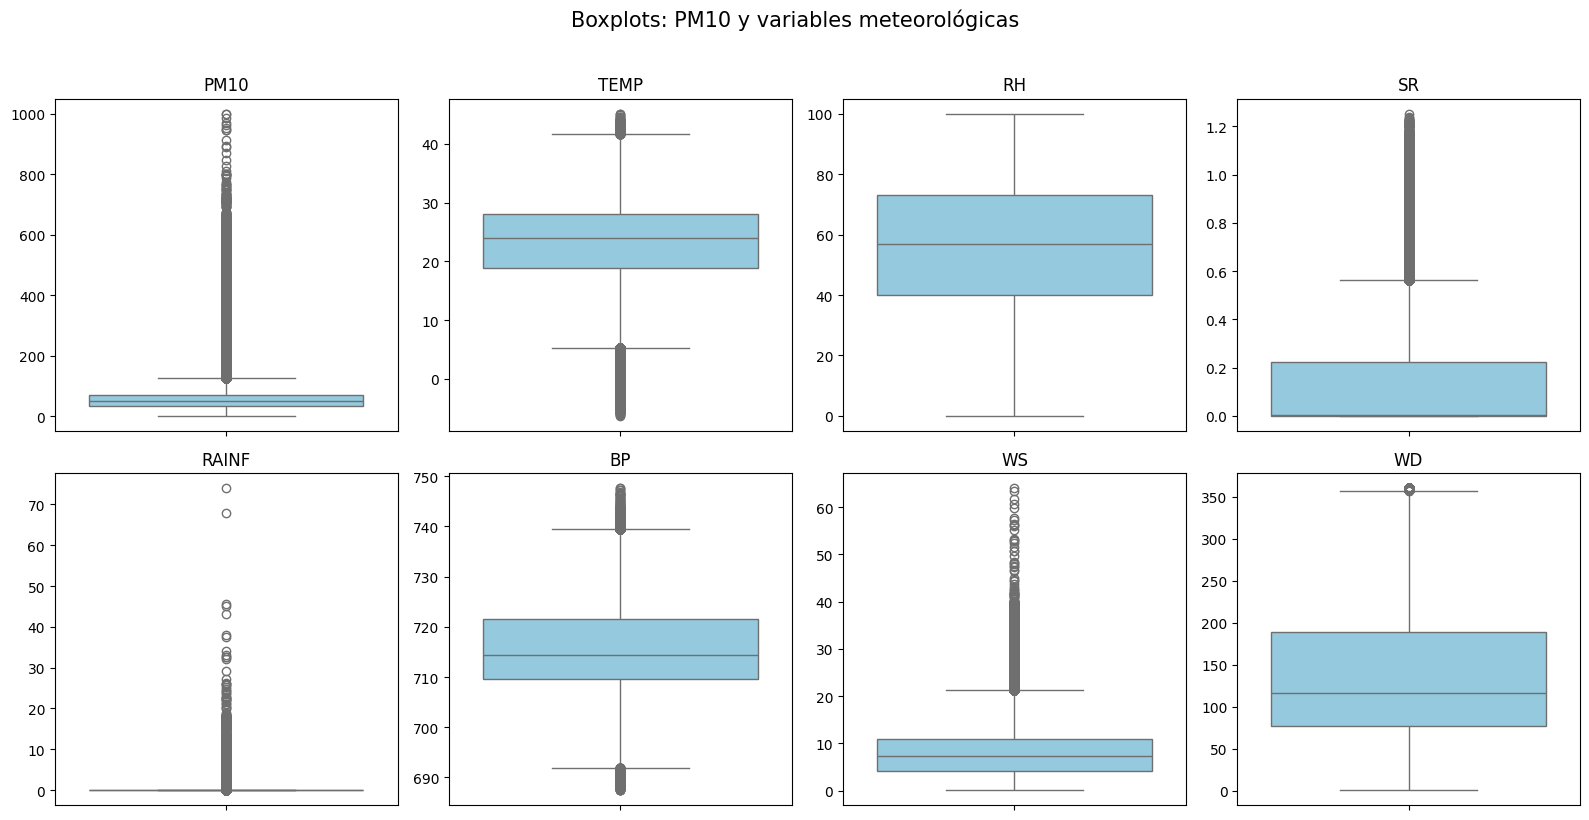

In [ ]:
n_vars = len(variables_meteo_pm10)
n_cols = 4
n_rows = -(-n_vars // n_cols)  # redondeo hacia arriba

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables_meteo_pm10):
    sns.boxplot(y=df_maestro[var], ax=axes[i], color='skyblue')
    axes[i].set_title(var)
    axes[i].set_ylabel('')

# Ocultar ejes sobrantes si el grid no se llena exacto
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots: PM10 y variables meteorológicas', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Histogramas
Distribución y asimetría

  Variable  Coef. de asimetría (skewness)  \
0     PM10                          3.728   
1     TEMP                         -0.406   
2       RH                         -0.422   
3       SR                          1.533   
4    RAINF                         40.649   
5       BP                          0.165   
6       WS                          1.032   
7       WD                          0.777   

                                     Forma  
0  Asimétrica positiva (cola a la derecha)  
1                Aproximadamente simétrica  
2                Aproximadamente simétrica  
3  Asimétrica positiva (cola a la derecha)  
4  Asimétrica positiva (cola a la derecha)  
5                Aproximadamente simétrica  
6  Asimétrica positiva (cola a la derecha)  
7  Asimétrica positiva (cola a la derecha)  


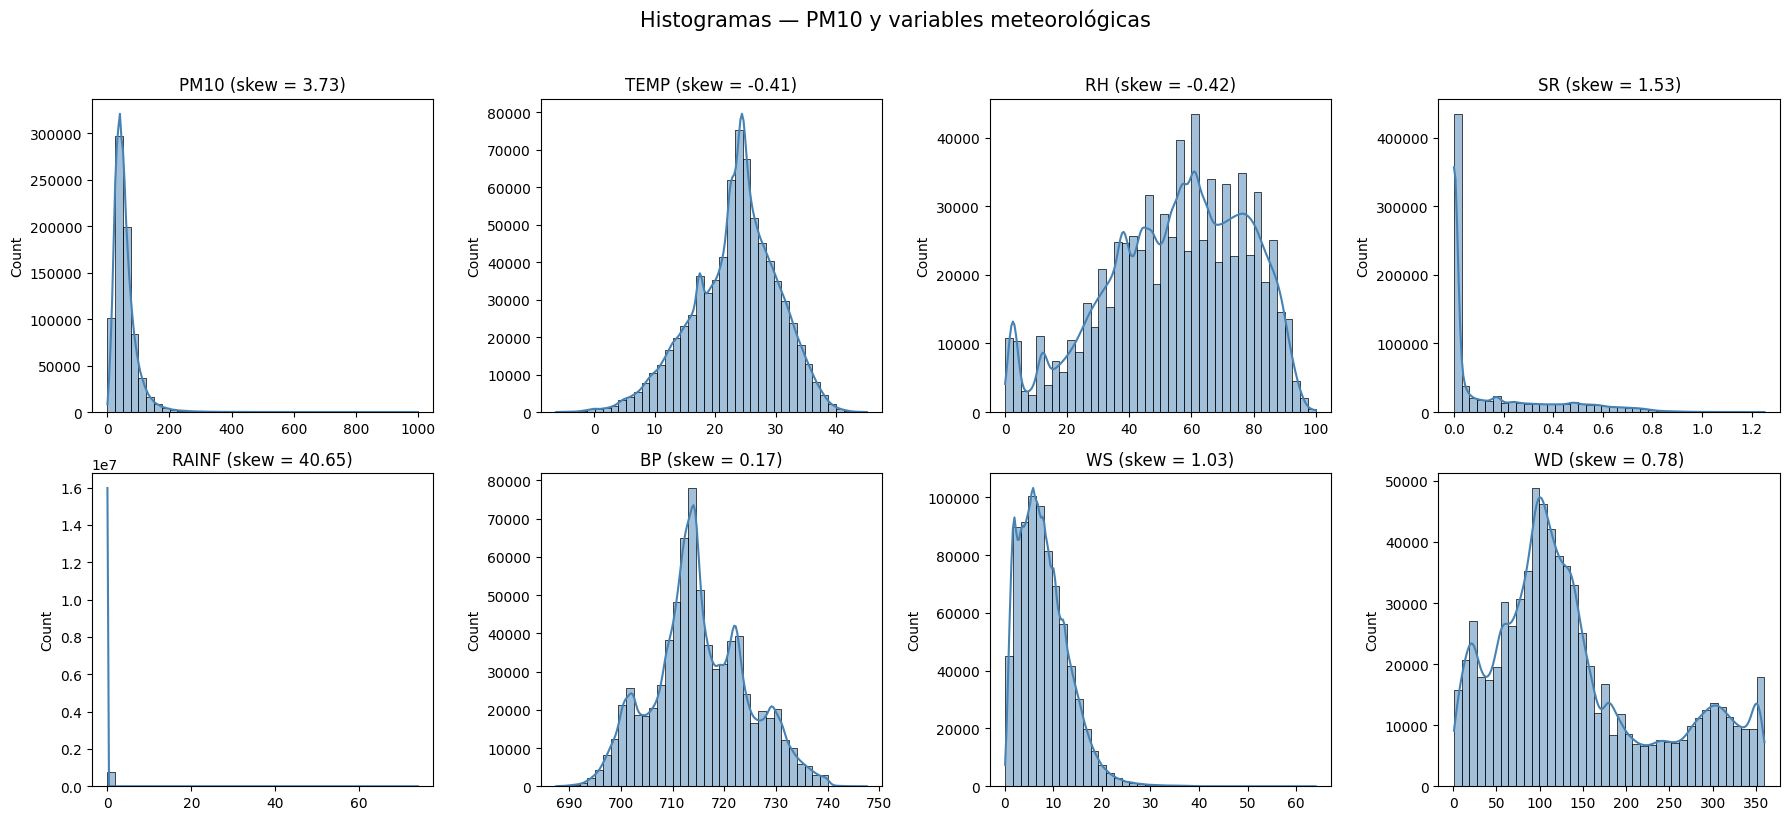

In [ ]:
from scipy.stats import skew

# Cálculo de la curtosis de cada variable (centrada en 0)
resumen_simetria = []

for var in variables_meteo_pm10:
    datos = df_maestro[var].dropna()
    coef = skew(datos)

    if coef > 0.5:
        forma = 'Asimétrica positiva (cola a la derecha)'
    elif coef < -0.5:
        forma = 'Asimétrica negativa (cola a la izquierda)'
    else:
        forma = 'Aproximadamente simétrica'

    resumen_simetria.append({
        'Variable': var,
        'Coef. de asimetría (skewness)': round(coef, 3),
        'Forma': forma
    })

df_simetria = pd.DataFrame(resumen_simetria)
print(df_simetria)

# Histogramas con curva de densidad
n_vars = len(variables_meteo_pm10)
n_cols = 4
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables_meteo_pm10):
    datos = df_maestro[var].dropna()
    sns.histplot(datos, kde=True, ax=axes[i], color='steelblue', bins=40)
    axes[i].set_title(f"{var} (skew = {skew(datos):.2f})")
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas — PM10 y variables meteorológicas', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Pruebas de normalidad

Tamaño de la muestra analizada: 754603 registros.

Normalidad Univariada (D'Agostino's K-squared)
PM10: p-value = 0.00e+00 -> No Normal (Rechaza H0)
TEMP: p-value = 0.00e+00 -> No Normal (Rechaza H0)
RH: p-value = 0.00e+00 -> No Normal (Rechaza H0)
SR: p-value = 0.00e+00 -> No Normal (Rechaza H0)
RAINF: p-value = 0.00e+00 -> No Normal (Rechaza H0)
BP: p-value = 0.00e+00 -> No Normal (Rechaza H0)
WS: p-value = 0.00e+00 -> No Normal (Rechaza H0)
WD: p-value = 0.00e+00 -> No Normal (Rechaza H0)


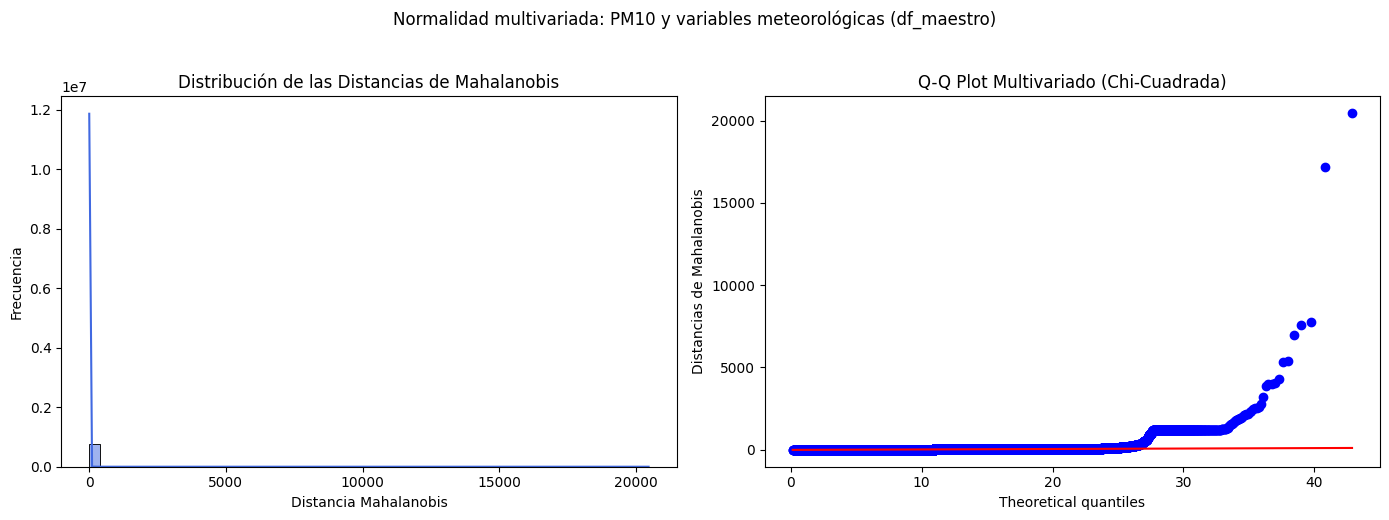

In [ ]:
# Pruebas de normalidad (uni y multivariada)

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

vars_to_test = ['PM10', 'TEMP', 'RH', 'SR', 'RAINF', 'BP', 'WS', 'WD']
vars_to_test = [v for v in vars_to_test if v in df_maestro.columns]

# Las pruebas multivariadas requieren casos completos, descartamos filas con nulos temporalmente
df_clean = df_maestro[vars_to_test].dropna()
print(f"Tamaño de la muestra analizada: {len(df_clean)} registros.\n")

# Normalidad univariada (Test de D'Agostino's K-squared)

print("Normalidad Univariada (D'Agostino's K-squared)")
resultados_univariados = []
for col in df_clean.columns:
    stat, p = stats.normaltest(df_clean[col])
    resultado = 'Normal' if p > 0.05 else 'No Normal (Rechaza H0)'
    resultados_univariados.append({'Variable': col, 'Estadístico': stat, 'p-value': p, 'Resultado': resultado})
    print(f"{col}: p-value = {p:.2e} -> {resultado}")

df_normalidad_uni = pd.DataFrame(resultados_univariados)

# Normalidad multivariada (Distancias de Mahalanobis)

cov_matrix = np.cov(df_clean.values.T)
inv_cov_matrix = np.linalg.inv(cov_matrix)
mean_vec = np.mean(df_clean.values, axis=0)

diff = df_clean.values - mean_vec
md = np.zeros(len(df_clean))
for i in range(len(df_clean)):
    md[i] = np.dot(np.dot(diff[i], inv_cov_matrix), diff[i].T)

df_chi2 = len(vars_to_test)  # Grados de libertad = número de variables

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(md, bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribución de las Distancias de Mahalanobis')
axes[0].set_xlabel('Distancia Mahalanobis')
axes[0].set_ylabel('Frecuencia')

stats.probplot(md, dist=stats.chi2, sparams=(df_chi2,), plot=axes[1])
axes[1].get_lines()[0].set_color('blue')
axes[1].get_lines()[1].set_color('red')
axes[1].set_title('Q-Q Plot Multivariado (Chi-Cuadrada)')
axes[1].set_ylabel('Distancias de Mahalanobis')

plt.suptitle('Normalidad multivariada: PM10 y variables meteorológicas (df_maestro)', y=1.03)
plt.tight_layout()
plt.show()

### 2) Verificación de limpieza
Doble verificación de la limpieza de los datos hecha en la etapa 1

In [ ]:
# Faltantes, erróneos, duplicados, errores de escritura

print("="*70)
print("1) VALORES FALTANTES")
print("="*70)
nulos = df_maestro.isnull().sum()
pct_nulos = 100 * nulos / len(df_maestro)
df_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos.round(2)})
df_nulos = df_nulos[df_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
print(df_nulos if not df_nulos.empty else "No se detectaron valores nulos.")

print("\n" + "="*70)
print("2) DUPLICADOS")
print("="*70)
# Duplicados exactos (todas las columnas)
dup_exactos = df_maestro.duplicated().sum()
print(f"Filas totalmente duplicadas: {dup_exactos}")

# Duplicados por clave lógica (misma estación, mismo timestamp)
if 'Fecha' in df_maestro.columns and 'Estación' in df_maestro.columns:
    dup_clave = df_maestro.duplicated(subset=['Fecha', 'Estación']).sum()
    print(f"Duplicados por (Fecha + Estación) — mismo registro repetido: {dup_clave}")

print("\n" + "="*70)
print("3) VALORES ERRÓNEOS — fuera de rango del fabricante (fuera de lo físicamente posible)")
print("="*70)
rango_fabricante = {
    'PM10': (0,1000), 'PM2.5': (0,1000), 'O3': (0,1000), 'NO': (0,500),
    'NO2': (0,500), 'NOX': (0,500), 'SO2': (0,500), 'CO': (0,50.0),
    'RH': (0,100), 'WS': (0,180), 'TEMP': (-50,50), 'SR': (0,1.40),
    'BP': (49.9,824), 'WD': (0,360),
}

errores_detectados = {}
for var, (vmin, vmax) in rango_fabricante.items():
    if var in df_maestro.columns:
        fuera_rango = df_maestro[(df_maestro[var] < vmin) | (df_maestro[var] > vmax)]
        if len(fuera_rango) > 0:
            errores_detectados[var] = len(fuera_rango)

if errores_detectados:
    for var, n in errores_detectados.items():
        print(f"{var}: {n} valores fuera del rango físico del sensor ({rango_fabricante[var]})")
else:
    print("No se detectaron valores fuera del rango físico del fabricante.")

print("\n" + "="*70)
print("4) ERRORES DE ESCRITURA — inconsistencias en columnas categóricas")
print("="*70)
if 'Estación' in df_maestro.columns:
    print("Valores únicos en 'Estación':")
    print(sorted(df_maestro['Estación'].unique()))

if 'Año' in df_maestro.columns:
    print("\nValores únicos en 'Año':")
    print(sorted(df_maestro['Año'].unique()))

# Espacios en blanco extra, mayúsculas/minúsculas inconsistentes en texto
for col in df_maestro.select_dtypes(include='object').columns:
    valores = df_maestro[col].dropna().astype(str)
    con_espacios = valores[valores != valores.str.strip()]
    if len(con_espacios) > 0:
        print(f"\n⚠ '{col}': {len(con_espacios)} valores con espacios extra al inicio/final")

print("\n" + "="*70)
print("5) TIPOS DE DATO POR COLUMNA")
print("="*70)
print(df_maestro.dtypes)

1) VALORES FALTANTES
       Nulos  % Nulos
PM2.5  44560     5.91
NO2    35107     4.65
NOX    26332     3.49
NO     26331     3.49
O3      8776     1.16

2) DUPLICADOS
Filas totalmente duplicadas: 0
Duplicados por (Fecha + Estación) — mismo registro repetido: 0

3) VALORES ERRÓNEOS — fuera de rango del fabricante (fuera de lo físicamente posible)
No se detectaron valores fuera del rango físico del fabricante.

4) ERRORES DE ESCRITURA — inconsistencias en columnas categóricas
Valores únicos en 'Estación':
['CE', 'NE', 'NE2', 'NE3', 'NO', 'NO2', 'NO3', 'NTE', 'NTE2', 'SE', 'SE2', 'SE3', 'SO', 'SO2', 'SUR']

Valores únicos en 'Año':
['2020', '2021', '2022', '2023', '2024', '2025']

5) TIPOS DE DATO POR COLUMNA
Fecha       datetime64[ns]
CO                 float64
NO                 float64
NO2                float64
NOX                float64
O3                 float64
PM10               float64
PM2.5              float64
BP                 float64
RAINF              float64
RH           

In [ ]:
# Exportar dataset limpio a CSV
df_maestro.to_csv('dataset_limpio_SIMA.csv', index=False, encoding='utf-8-sig')